## 14.05节练习参考答案

### 环境准备

In [ ]:
import os, sys
os.environ["TILE_FWK_DEVICE_ID"] = "0"

# 本 notebook 位于 answers/ 子目录下，src 包在其上一级目录。
# 把上层目录加入 sys.path，才能 from src.utils import ...；
# 同时把工作目录切到章节根目录，使 "../data" 数据缓存与主 notebook 一致。
if os.path.isdir("../src"):
    sys.path.insert(0, os.path.abspath(".."))
    os.chdir("..")

# 固定 PyPTO 编译缓存目录（与第 11 章共享 d2l_ai_pypto/ptile_cache）：
# 内核/Jupyter 重启后无需从零重新编译算子。
# PTO_TILE_LIB_CODE_PATH 目录还必须包含 include/pto（pto-isa 头文件），
# 否则算子编译时报 PTO_ISA_NOT_FOUND；用软链指向 CANN 自带的头文件即可。
os.environ["PTO_TILE_LIB_CODE_PATH"] = os.path.abspath("../ptile_cache")
_pto_lib = os.environ["PTO_TILE_LIB_CODE_PATH"]
os.makedirs(os.path.join(_pto_lib, "include"), exist_ok=True)
_pto_isa_link = os.path.join(_pto_lib, "include", "pto")
if not os.path.exists(_pto_isa_link):
    import glob
    _isa_candidates = glob.glob(os.path.expanduser(
        "~/Ascend/cann-*/aarch64-linux/include/pto"))
    if _isa_candidates:
        os.symlink(os.path.abspath(_isa_candidates[0]), _pto_isa_link)
    else:
        raise RuntimeError("未找到 pto-isa 头文件目录（~/Ascend/cann-*/aarch64-linux/include/pto）")

import torch
from torch import nn
from torch.nn import functional as F

from src.utils import (TokenEmbedding, load_data_snli,
                       train_ch13, try_all_gpus)
from src.pto_layers import PyPTOLinear, PyPTOReLU

本节的解答思路参考了 [《动手学深度学习》习题解答](https://datawhalechina.github.io/d2l-ai-solutions-manual/#/ch15/ch15)，并在此基础上补充了 PyPTO 的实现。

### 练习14.5.1
使用其他超参数组合训练模型，能在测试集上获得更高的准确度吗？

**解答：**

通过调节超参数组合，将所得的结果整理如下（注意每次训练的结果都有微小差别）：

<table style="text-align: left; border-collapse: collapse;">
  <thead>
    <tr><th style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">实现</th><th style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">batch_size</th><th style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">num_steps</th><th style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">learning rate</th><th style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">num_epochs</th><th style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">result</th></tr>
  </thead>
  <tbody>
    <tr><td style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">PyTorch</td><td style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">256</td><td style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">50</td><td style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">0.001</td><td style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">4</td><td style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">loss 0.494, train acc 0.806, test acc 0.828</td></tr>
    <tr><td style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">PyTorch</td><td style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">256</td><td style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">50</td><td style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">0.001</td><td style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">8</td><td style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">loss 0.440, train acc 0.830, test acc 0.832</td></tr>
    <tr><td style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">PyTorch</td><td style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">512</td><td style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">50</td><td style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">0.001</td><td style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">8</td><td style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">loss 0.442, train acc 0.829, test acc 0.832</td></tr>
    <tr><td style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">PyPTO</td><td style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">256</td><td style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">50</td><td style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">0.001</td><td style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">4</td><td style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">loss 0.500, train acc 0.803, test acc 0.822</td></tr>
    <tr><td style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">PyPTO</td><td style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">256</td><td style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">50</td><td style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">0.001</td><td style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">8</td><td style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">loss 0.448, train acc 0.827, test acc 0.835</td></tr>
    <tr><td style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">PyPTO</td><td style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">512</td><td style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">50</td><td style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">0.001</td><td style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">8</td><td style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">loss 0.446, train acc 0.828, test acc 0.831</td></tr>
  </tbody>
</table>

从表格可以看出，其他超参数不变时，将训练轮数从 4 增加到 8 可以提高测试精度；继续增大 `batch_size` 到 512 收益不明显。测试集精度最好的组合是 `batch_size = 256, num_steps = 50, learning rate = 0.001, num_epochs = 8`，PyPTO 版可达 83.5%（PyTorch 版为 83.2%）。

In [3]:
# 注意
def mlp(num_inputs, num_hiddens, flatten):
    net = []
    net.append(nn.Dropout(0.2))
    net.append(nn.Linear(num_inputs, num_hiddens))
    net.append(nn.ReLU())
    if flatten:
        net.append(nn.Flatten(start_dim=1))
    net.append(nn.Dropout(0.2))
    net.append(nn.Linear(num_hiddens, num_hiddens))
    net.append(nn.ReLU())
    if flatten:
        net.append(nn.Flatten(start_dim=1))
    return nn.Sequential(*net)
class Attend(nn.Module):
    def __init__(self, num_inputs, num_hiddens, **kwargs):
        super(Attend, self).__init__(**kwargs)
        self.f = mlp(num_inputs, num_hiddens, flatten=False)

    def forward(self, A, B):
        # A/B的形状：（批量大小，序列A/B的词元数，embed_size）
        # f_A/f_B的形状：（批量大小，序列A/B的词元数，num_hiddens）
        f_A = self.f(A)
        f_B = self.f(B)
        # e的形状：（批量大小，序列A的词元数，序列B的词元数）
        e = torch.bmm(f_A, f_B.permute(0, 2, 1))
        # beta的形状：（批量大小，序列A的词元数，embed_size），
        # 意味着序列B被软对齐到序列A的每个词元(beta的第1个维度)
        beta = torch.bmm(F.softmax(e, dim=-1), B)
        # beta的形状：（批量大小，序列B的词元数，embed_size），
        # 意味着序列A被软对齐到序列B的每个词元(alpha的第1个维度)
        alpha = torch.bmm(F.softmax(e.permute(0, 2, 1), dim=-1), A)
        return beta, alpha
    
# 比较
class Compare(nn.Module):
    def __init__(self, num_inputs, num_hiddens, **kwargs):
        super(Compare, self).__init__(**kwargs)
        self.g = mlp(num_inputs, num_hiddens, flatten=False)

    def forward(self, A, B, beta, alpha):
        V_A = self.g(torch.cat([A, beta], dim=2))
        V_B = self.g(torch.cat([B, alpha], dim=2))
        return V_A, V_B
    
# 聚合
class Aggregate(nn.Module):
    def __init__(self, num_inputs, num_hiddens, num_outputs, **kwargs):
        super(Aggregate, self).__init__(**kwargs)
        self.h = mlp(num_inputs, num_hiddens, flatten=True)
        self.linear = nn.Linear(num_hiddens, num_outputs)

    def forward(self, V_A, V_B):
        # 对两组比较向量分别求和
        V_A = V_A.sum(dim=1)
        V_B = V_B.sum(dim=1)
        # 将两个求和结果的连结送到多层感知机中
        Y_hat = self.linear(self.h(torch.cat([V_A, V_B], dim=1)))
        return Y_hat


In [4]:
# 定义可分解注意力模型
class DecomposableAttention(nn.Module):
    def __init__(self, vocab, embed_size, num_hiddens, num_inputs_attend=100,
                 num_inputs_compare=200, num_inputs_agg=400, **kwargs):
        super(DecomposableAttention, self).__init__(**kwargs)
        self.embedding = nn.Embedding(len(vocab), embed_size)
        self.attend = Attend(num_inputs_attend, num_hiddens)
        self.compare = Compare(num_inputs_compare, num_hiddens)
        # 有3种可能的输出：蕴涵、矛盾和中性
        self.aggregate = Aggregate(num_inputs_agg, num_hiddens, num_outputs=3)

    def forward(self, X):
        premises, hypotheses = X
        A = self.embedding(premises)
        B = self.embedding(hypotheses)
        beta, alpha = self.attend(A, B)
        V_A, V_B = self.compare(A, B, beta, alpha)
        Y_hat = self.aggregate(V_A, V_B)
        return Y_hat


loss 0.494, train acc 0.806, test acc 0.828
31421.1 examples/sec on [device(type='npu', index=0), device(type='npu', index=1)]


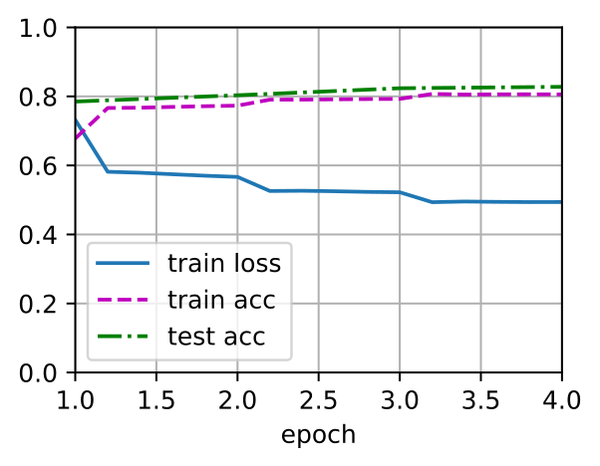

In [5]:
# 读取数据集
batch_size, num_steps = 256, 50
train_iter, test_iter, vocab = load_data_snli(batch_size, num_steps)

# 创建模型
embed_size, num_hiddens, devices = 100, 200, try_all_gpus()
net = DecomposableAttention(vocab, embed_size, num_hiddens)
glove_embedding = TokenEmbedding('glove.6b.100d')
embeds = glove_embedding[vocab.idx_to_token]
net.embedding.weight.data.copy_(embeds);

# 训练和评估模型
lr, num_epochs = 0.001, 4
trainer = torch.optim.Adam(net.parameters(), lr=lr)
loss = nn.CrossEntropyLoss(reduction="none")
train_ch13(net, train_iter, test_iter, loss, trainer, num_epochs, devices)


loss 0.440, train acc 0.830, test acc 0.832
31794.1 examples/sec on [device(type='npu', index=0), device(type='npu', index=1)]


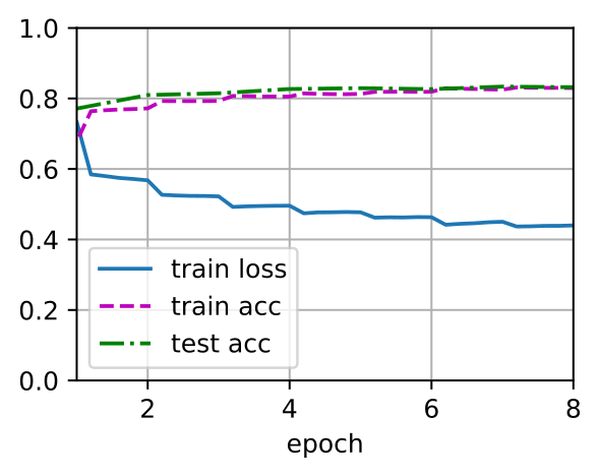

In [6]:
# 读取数据集
batch_size, num_steps = 256, 50
train_iter, test_iter, vocab = load_data_snli(batch_size, num_steps)

# 创建模型
embed_size, num_hiddens, devices = 100, 200, try_all_gpus()
net = DecomposableAttention(vocab, embed_size, num_hiddens)
glove_embedding = TokenEmbedding('glove.6b.100d')
embeds = glove_embedding[vocab.idx_to_token]
net.embedding.weight.data.copy_(embeds);

# 训练和评估模型
lr, num_epochs = 0.001, 8
trainer = torch.optim.Adam(net.parameters(), lr=lr)
loss = nn.CrossEntropyLoss(reduction="none")
train_ch13(net, train_iter, test_iter, loss, trainer, num_epochs, devices)


loss 0.442, train acc 0.829, test acc 0.832
58006.3 examples/sec on [device(type='npu', index=0), device(type='npu', index=1)]


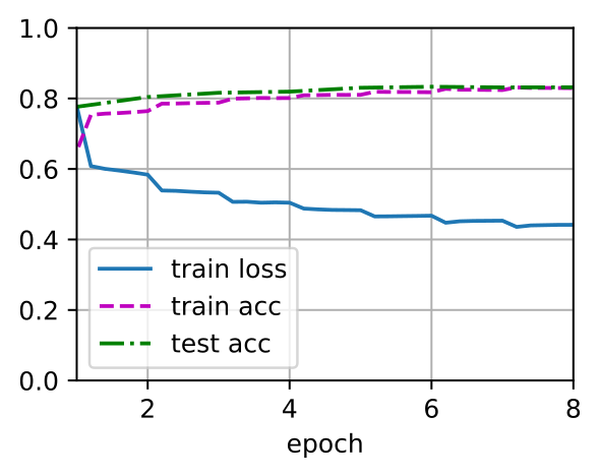

In [7]:
# 读取数据集
batch_size, num_steps = 512, 50
train_iter, test_iter, vocab = load_data_snli(batch_size, num_steps)

# 创建模型
embed_size, num_hiddens, devices = 100, 200, try_all_gpus()
net = DecomposableAttention(vocab, embed_size, num_hiddens)
glove_embedding = TokenEmbedding('glove.6b.100d')
embeds = glove_embedding[vocab.idx_to_token]
net.embedding.weight.data.copy_(embeds);

# 训练和评估模型
lr, num_epochs = 0.001, 8
trainer = torch.optim.Adam(net.parameters(), lr=lr)
loss = nn.CrossEntropyLoss(reduction="none")
train_ch13(net, train_iter, test_iter, loss, trainer, num_epochs, devices)


**PyPTO 版**

In [2]:
# ---- PyPTO 预热（防死锁，必须执行）----
# 不预热时，首个 PyPTO kernel 会卡死在 tile 框架设备初始化
# （DeviceRunner::Get 死锁：NPU 利用率 0%、编译缓存无输出、训练永不出图）。
# 修复：先显式 set_device，再 DeviceInit，然后跑一个无关的小算子预热。
import pypto
import torch_npu  # noqa: F401
_dev = f"npu:{os.environ['TILE_FWK_DEVICE_ID']}"
torch.npu.set_device(int(os.environ['TILE_FWK_DEVICE_ID']))
pypto.pypto_impl.DeviceInit()

@pypto.frontend.jit(runtime_options={"run_mode": pypto.RunMode.NPU})
def _warmup_kernel(a: pypto.Tensor([], pypto.DT_FP32),
                   b: pypto.Tensor([], pypto.DT_FP32)):
    pypto.set_vec_tile_shapes(128, 128)
    b.move(pypto.sigmoid(a))

_wa = torch.randn(32, 256, device=_dev)
_wb = torch.empty(32, 256, device=_dev)
_warmup_kernel(_wa, _wb)
torch.npu.synchronize()
del _wa, _wb
print("PyPTO warmup done")

PyPTO warmup done


In [3]:
# 注意
def mlp(num_inputs, num_hiddens, flatten):
    net = []
    net.append(nn.Dropout(0.2))
    net.append(PyPTOLinear(num_inputs, num_hiddens))
    net.append(PyPTOReLU())
    if flatten:
        net.append(nn.Flatten(start_dim=1))
    net.append(nn.Dropout(0.2))
    net.append(PyPTOLinear(num_hiddens, num_hiddens))
    net.append(nn.ReLU())
    if flatten:
        net.append(nn.Flatten(start_dim=1))
    return nn.Sequential(*net)
class Attend(nn.Module):
    def __init__(self, num_inputs, num_hiddens, **kwargs):
        super(Attend, self).__init__(**kwargs)
        self.f = mlp(num_inputs, num_hiddens, flatten=False)

    def forward(self, A, B):
        # A/B的形状：（批量大小，序列A/B的词元数，embed_size）
        # f_A/f_B的形状：（批量大小，序列A/B的词元数，num_hiddens）
        f_A = self.f(A)
        f_B = self.f(B)
        # e的形状：（批量大小，序列A的词元数，序列B的词元数）
        e = torch.bmm(f_A, f_B.permute(0, 2, 1))
        # beta的形状：（批量大小，序列A的词元数，embed_size），
        # 意味着序列B被软对齐到序列A的每个词元(beta的第1个维度)
        beta = torch.bmm(F.softmax(e, dim=-1), B)
        # beta的形状：（批量大小，序列B的词元数，embed_size），
        # 意味着序列A被软对齐到序列B的每个词元(alpha的第1个维度)
        alpha = torch.bmm(F.softmax(e.permute(0, 2, 1), dim=-1), A)
        return beta, alpha
    
# 比较
class Compare(nn.Module):
    def __init__(self, num_inputs, num_hiddens, **kwargs):
        super(Compare, self).__init__(**kwargs)
        self.g = mlp(num_inputs, num_hiddens, flatten=False)

    def forward(self, A, B, beta, alpha):
        V_A = self.g(torch.cat([A, beta], dim=2))
        V_B = self.g(torch.cat([B, alpha], dim=2))
        return V_A, V_B
    
# 聚合
class Aggregate(nn.Module):
    def __init__(self, num_inputs, num_hiddens, num_outputs, **kwargs):
        super(Aggregate, self).__init__(**kwargs)
        self.h = mlp(num_inputs, num_hiddens, flatten=True)
        self.linear = PyPTOLinear(num_hiddens, num_outputs)

    def forward(self, V_A, V_B):
        # 对两组比较向量分别求和
        V_A = V_A.sum(dim=1)
        V_B = V_B.sum(dim=1)
        # 将两个求和结果的连结送到多层感知机中
        Y_hat = self.linear(self.h(torch.cat([V_A, V_B], dim=1)))
        return Y_hat


In [4]:
# 定义可分解注意力模型
class DecomposableAttention(nn.Module):
    def __init__(self, vocab, embed_size, num_hiddens, num_inputs_attend=100,
                 num_inputs_compare=200, num_inputs_agg=400, **kwargs):
        super(DecomposableAttention, self).__init__(**kwargs)
        self.embedding = nn.Embedding(len(vocab), embed_size)
        self.attend = Attend(num_inputs_attend, num_hiddens)
        self.compare = Compare(num_inputs_compare, num_hiddens)
        # 有3种可能的输出：蕴涵、矛盾和中性
        self.aggregate = Aggregate(num_inputs_agg, num_hiddens, num_outputs=3)

    def forward(self, X):
        premises, hypotheses = X
        A = self.embedding(premises)
        B = self.embedding(hypotheses)
        beta, alpha = self.attend(A, B)
        V_A, V_B = self.compare(A, B, beta, alpha)
        Y_hat = self.aggregate(V_A, V_B)
        return Y_hat

loss 0.500, train acc 0.803, test acc 0.822
821.2 examples/sec on [device(type='npu', index=0), device(type='npu', index=1)]


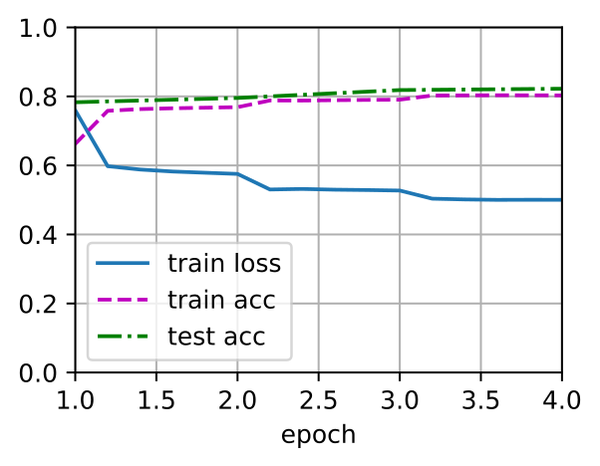

In [5]:
# 读取数据集
batch_size, num_steps = 256, 50
train_iter, test_iter, vocab = load_data_snli(batch_size, num_steps)

# 创建模型
embed_size, num_hiddens, devices = 100, 200, try_all_gpus()
net = DecomposableAttention(vocab, embed_size, num_hiddens)
glove_embedding = TokenEmbedding('glove.6b.100d')
embeds = glove_embedding[vocab.idx_to_token]
net.embedding.weight.data.copy_(embeds);

# 训练和评估模型
lr, num_epochs = 0.001, 4
trainer = torch.optim.Adam(net.parameters(), lr=lr)
loss = nn.CrossEntropyLoss(reduction="none")
train_ch13(net, train_iter, test_iter, loss, trainer, num_epochs, devices)


loss 0.448, train acc 0.827, test acc 0.835
952.6 examples/sec on [device(type='npu', index=0), device(type='npu', index=1)]


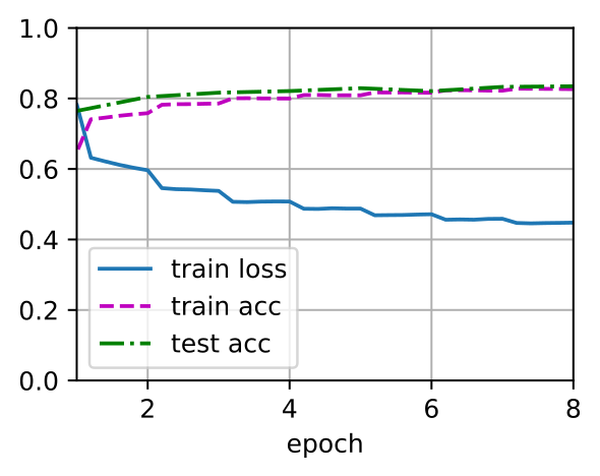

In [6]:
# 读取数据集
batch_size, num_steps = 256, 50
train_iter, test_iter, vocab = load_data_snli(batch_size, num_steps)

# 创建模型
embed_size, num_hiddens, devices = 100, 200, try_all_gpus()
net = DecomposableAttention(vocab, embed_size, num_hiddens)
glove_embedding = TokenEmbedding('glove.6b.100d')
embeds = glove_embedding[vocab.idx_to_token]
net.embedding.weight.data.copy_(embeds);

# 训练和评估模型
lr, num_epochs = 0.001, 8
trainer = torch.optim.Adam(net.parameters(), lr=lr)
loss = nn.CrossEntropyLoss(reduction="none")
train_ch13(net, train_iter, test_iter, loss, trainer, num_epochs, devices)

loss 0.446, train acc 0.828, test acc 0.831
863.4 examples/sec on [device(type='npu', index=0), device(type='npu', index=1)]


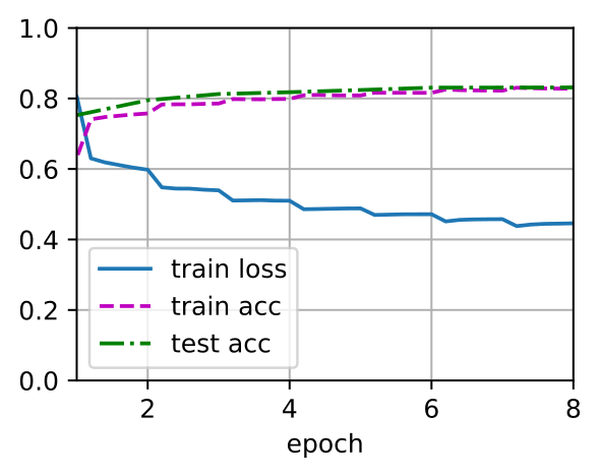

In [7]:
# 读取数据集
batch_size, num_steps = 512, 50
train_iter, test_iter, vocab = load_data_snli(batch_size, num_steps)

# 创建模型
embed_size, num_hiddens, devices = 100, 200, try_all_gpus()
net = DecomposableAttention(vocab, embed_size, num_hiddens)
glove_embedding = TokenEmbedding('glove.6b.100d')
embeds = glove_embedding[vocab.idx_to_token]
net.embedding.weight.data.copy_(embeds);

# 训练和评估模型
lr, num_epochs = 0.001, 8
trainer = torch.optim.Adam(net.parameters(), lr=lr)
loss = nn.CrossEntropyLoss(reduction="none")
train_ch13(net, train_iter, test_iter, loss, trainer, num_epochs, devices)

### 练习14.5.2
自然语言推断的可分解注意模型的主要缺点是什么？

**解答：**

自然语言推断（Natural Language Inference, NLI）是一种探究自然语言文本之间逻辑关系的技术，可用于识别文本之间的关联性、推理结论等等。可分解注意模型（Decomposable Attention Model）是在NLI任务中广泛应用的模型之一，它使用了注意力机制和神经网络来实现文本比较和推断加工。它被认为是一个具有效果显著的模型，但是它也存在一些主要缺点，这些缺点包括以下几个方面：

1. 上下文无关性：可分解注意模型在处理文本时不考虑上下文，这使得它无法识别一些依赖上下文才能确定语义的词汇和短语。可分解注意模型仅仅基于词汇和短语本身进行推断，因此无法获得更深层次的语意。

2. 描述限制性：可分解注意模型的处理能力也受到其内部描述的限制。该模型所使用的神经网络仅能处理输入数据中的某些特定方面，如词汇、语法、句法等，但忽略了一些其他方面，比如书面语的后缀式表达、重音、语气等。这些方面对于文本推断任务来说至关重要，如果无法捕捉到这些特征，会导致模型推断的精度下降。

3. 训练困难：可分解注意模型的训练需要大量的数据，并且需要精心设置模型参数和超参数，这将带来训练成本的增加和收敛速度的降低。此外，可分解注意模型的推理过程基于向量间的抽象表示，这意味着模型的收敛是受到维数灾难的影响的，因为在高维空间中，距离的计算和推理变得更加困难。综上所述，尽管可分解注意模型是一个被广泛使用的NLI模型，并且它取得了一定的成果，但是其存在一些重要的缺点，这些缺点限制了模型能力的提高和应用领域的扩展。


### 练习14.5.3
假设我们想要获得任何一对句子的语义相似级别（例如，0～1之间的连续值）。我们应该如何收集和标注数据集？请尝试设计一个有注意力机制的模型。

**解答：**

要获得句子之间的语义相似度，需要收集一个包含句子对及其相似程度的标注数据集。下面是一些可能的方法来构建这样的数据集：

1. 众包标注：可以使用在线平台，如Amazon Mechanical Turk等，招募众包工人来对句子对之间的语义相似程度进行标注。在这个过程中，众包工人将对给定句子对的相似程度进行打分。最后基于多位标注者的平均或者多数表决来确定标注值。
2. 专家标注：在这种方法中，专家可以被邀请来对句子对之间的语义相似程度进行标注。这可以通过招募领域专家或者语义学家来实现。

在标注数据集收集完毕之后，就可以考虑构建一个具有注意力机制的模型来进行语义相似性计算。以下是一种可能的基于注意力机制的模型架构：

1. 句子编码器：对于每个输入句子，使用一个预训练的词嵌入模型（如Word2Vec或GloVe）来将其编码成一个向量表示。
2. 对齐层：将两个句子的向量表示输入到一个对齐层中，该层使用注意力机制来计算句子之间词汇级别的相似度，将对齐后的向量表示返回。
3. 推理层：将对齐后的向量表示作为输入，送入多层感知机并用单个 sigmoid 输出单元，以回归的方式输出 0～1 之间的连续值，即句子对之间的语义相似度得分。使用正则化技术（如dropout）和一些常见的训练技巧（如批处理、学习率调整等），可以训练出具有良好泛化能力的语义相似度计算模型。